In [1]:
# =============================================================================
# GUS02C: Data Unification & Inspection
# =============================================================================
# This notebook demonstrates the v4.2 unification capabilities:
#   1. Load the complete database (from GUS02A/GUS02B)
#   2. Inspect time series (pd.Series with DatetimeIndex)
#   3. Inspect population data (TERYTRecord.pop)
#   4. Inspect urban/rural classification (TERYTRecord.pop_class)
#   5. Inspect category coding (DataSeries.cat_code, cat_bounds)
# =============================================================================

# STEP 1: Imports and Path Setup
import os
import sys
from pathlib import Path
import importlib
import gc
import random

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Find the repository root
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / 'Code').exists() or (p / '.git').exists():
            return p
    return start

repo_root = find_repo_root()
tools_path = repo_root / 'Code' / 'tools'
if str(tools_path) not in sys.path:
    sys.path.insert(0, str(tools_path))

import geoTERYT_db as gtdb
importlib.reload(gtdb)

# Paths
data_root = repo_root.parent.parent / 'Data'
geo_root = data_root / 'Geospatial'
gus_root = data_root / 'GUS'

print(f"Repository root: {repo_root}")
print(f"GUS root: {gus_root}")

Repository root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper
GUS root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/GUS


In [2]:
# =============================================================================
# STEP 2: Load Database
# =============================================================================
complete_db_path = geo_root / 'geoteryt_complete_final.pkl'
db = gtdb.load_complete_database(complete_db_path)
db.print_summary()
print(f"\nData summary: {db.get_data_summary()}")

Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_final.pkl...
  Database version: 4.2
  ✓ Restored geometry data for years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  ✓ Loaded 4561 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 3612
  ✓ Records with old_woj: 2658
  ✓ Records with data: 4533
  ✓ Records with cross tables: 4533
  ✓ Records with population data: 4533
  ✓ Records with pop_class: 3411
GeoTERYT Database Summary (v3.0)
Total records:           4,561
Year range:              1999 - 2024
------------------------------------------------------------
Administrative levels:
  Voivodeships (2):      16
  Powiats (5):           382
  Gminas (6):            4162
------------------------------------------------------------
Change tracking:
  Records with changes:      772
  Records with level ch

In [3]:
# =============================================================================
# STEP 3: Pick a Random TERYTRecord (level=6, with data)
# =============================================================================
# Randomly draw a gmina-level record that has population data

candidates = [r for r in db._records.values() 
              if r.level == 6 and r.has_data and r.pop.notna().any()]
random.seed(42)  # For reproducibility
rec = random.choice(candidates)

print(f"Randomly selected record: {rec.teryt_id} - {rec.name}")
print(f"  Level: {rec.level}, Kind: {rec.kind}, Rodz: {rec.rodz}")
print(f"  Has data: {rec.has_data}, Data series: {rec.n_data_series}")
print(f"  Has cross tables: {rec.has_cross_tables}")
print(f"  Subjects: {rec.list_subjects()}")
print(f"\n--- Full record dict ---")
rec.to_dict()

Randomly selected record: 1002102 - Strzelce
  Level: 6, Kind: rural, Rodz: 2
  Has data: True, Data series: 434
  Has cross tables: True
  Subjects: ['P2871', 'P2887', 'M_pop__age_sex', 'M_pop__sex_educ', 'P2114', 'M_hh_size', 'P2402', 'P4315', 'P2883', 'P3304', 'P4287', 'P2885', 'P2137', 'P2884', 'P4253']

--- Full record dict ---


{'teryt_id': '1002102',
 'name': 'Strzelce',
 'name_dod': 'gmina wiejska',
 'level': 6,
 'kind': 'rural',
 'woj': '10',
 'pow': '02',
 'gmi': '10',
 'rodz': '2',
 'years_valid': [np.int64(1999),
  np.int64(2000),
  np.int64(2001),
  np.int64(2002),
  np.int64(2003),
  np.int64(2004),
  np.int64(2005),
  np.int64(2006),
  np.int64(2007),
  np.int64(2008),
  np.int64(2009),
  np.int64(2010),
  np.int64(2011),
  np.int64(2012),
  np.int64(2013),
  np.int64(2014),
  np.int64(2015),
  np.int64(2016),
  np.int64(2017),
  np.int64(2018),
  np.int64(2019),
  np.int64(2020),
  np.int64(2021),
  np.int64(2022),
  np.int64(2023),
  np.int64(2024)],
 'first_year': np.int64(1999),
 'last_year': np.int64(2024),
 'past_names': [],
 'past_teryt_ids': [],
 'past_levels': [],
 'past_kinds': [],
 'all_teryt_ids': ['1002102'],
 'all_names': ['Strzelce'],
 'changes': [],
 'has_changes': False,
 'n_changes': 0,
 'has_geometry': True,
 'geometry_year': 2005,
 'geometry_notes': 'assigned_from_year_2005',
 'ol

=== Time Series for 1002102 (Strzelce) ===

DataSeries: DataSeries(BDL/P2137/47693, cats=[n1=60-64, n2=kobiety], 30 years [1995-2024])
  Type of values: <class 'pandas.core.series.Series'>
  Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
  Years with data: [1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

--- Full pd.Series ---


1988-01-01      NaN
1989-01-01      NaN
1990-01-01      NaN
1991-01-01      NaN
1992-01-01      NaN
1993-01-01      NaN
1994-01-01      NaN
1995-01-01    101.0
1996-01-01    107.0
1997-01-01    104.0
1998-01-01    108.0
1999-01-01    123.0
2000-01-01    125.0
2001-01-01    119.0
2002-01-01    115.0
2003-01-01    103.0
2004-01-01     91.0
2005-01-01     87.0
2006-01-01    101.0
2007-01-01    107.0
2008-01-01    115.0
2009-01-01    125.0
2010-01-01    124.0
2011-01-01    109.0
2012-01-01    114.0
2013-01-01    113.0
2014-01-01    120.0
2015-01-01    136.0
2016-01-01    149.0
2017-01-01    141.0
2018-01-01    153.0
2019-01-01    149.0
2020-01-01    133.0
2021-01-01    118.0
2022-01-01    120.0
2023-01-01    113.0
2024-01-01    107.0
2025-01-01      NaN
dtype: float64

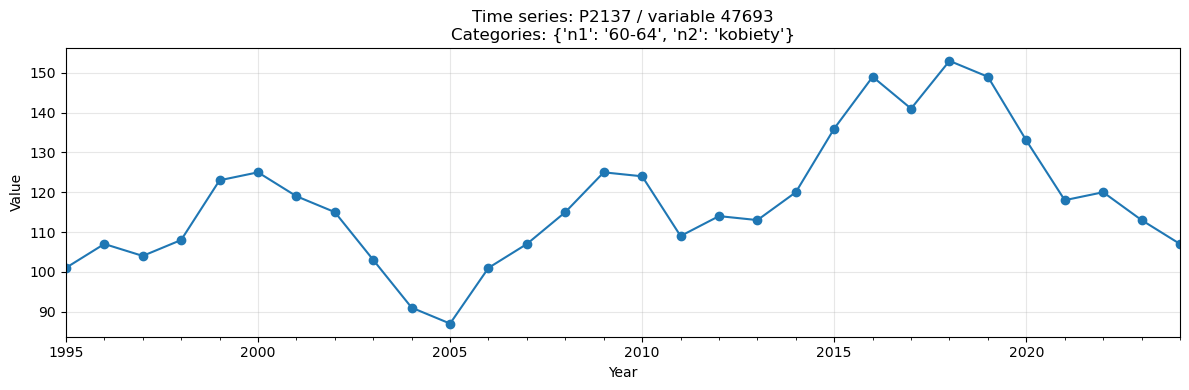

In [4]:
# =============================================================================
# STEP 4: Time Series Demo (pd.Series with DatetimeIndex)
# =============================================================================
# Show that data is now stored as pd.Series indexed by datetime

print(f"=== Time Series for {rec.teryt_id} ({rec.name}) ===\n")

# Pick the first DataSeries
if rec.data:
    first_key = list(rec.data.keys())[0]
    ds = rec.data[first_key]
    print(f"DataSeries: {ds}")
    print(f"  Type of values: {type(ds.values)}")
    print(f"  Index type: {type(ds.values.index)}")
    print(f"  Years with data: {ds.years}")
    print(f"\n--- Full pd.Series ---")
    display(ds.values)
    
    # Plot the time series
    fig, ax = plt.subplots(figsize=(12, 4))
    ds.values.dropna().plot(ax=ax, marker='o', linewidth=1.5)
    ax.set_title(f"Time series: {ds.subject_id} / variable {ds.variable_id}\n"
                 f"Categories: {ds.categories}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

=== Population for 1002102 (Strzelce) ===

Type: <class 'pandas.core.series.Series'>
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Years with data: [1988, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

--- Population time series ---


1988-01-01    4865.0
1989-01-01       NaN
1990-01-01       NaN
1991-01-01       NaN
1992-01-01       NaN
1993-01-01       NaN
1994-01-01       NaN
1995-01-01    4615.0
1996-01-01    4596.0
1997-01-01    4571.0
1998-01-01    4557.0
1999-01-01    4483.0
2000-01-01    4399.0
2001-01-01    4399.0
2002-01-01    4322.0
2003-01-01    4272.0
2004-01-01    4272.0
2005-01-01    4217.0
2006-01-01    4193.0
2007-01-01    4141.0
2008-01-01    4100.0
2009-01-01    4100.0
2010-01-01    4118.0
2011-01-01    4114.0
2012-01-01    4086.0
2013-01-01    4050.0
2014-01-01    4065.0
2015-01-01    4059.0
2016-01-01    4023.0
2017-01-01    3969.0
2018-01-01    3947.0
2019-01-01    3913.0
2020-01-01    3798.0
2021-01-01    3785.0
2022-01-01    3743.0
2023-01-01    3720.0
2024-01-01    3686.0
2025-01-01       NaN
dtype: float64

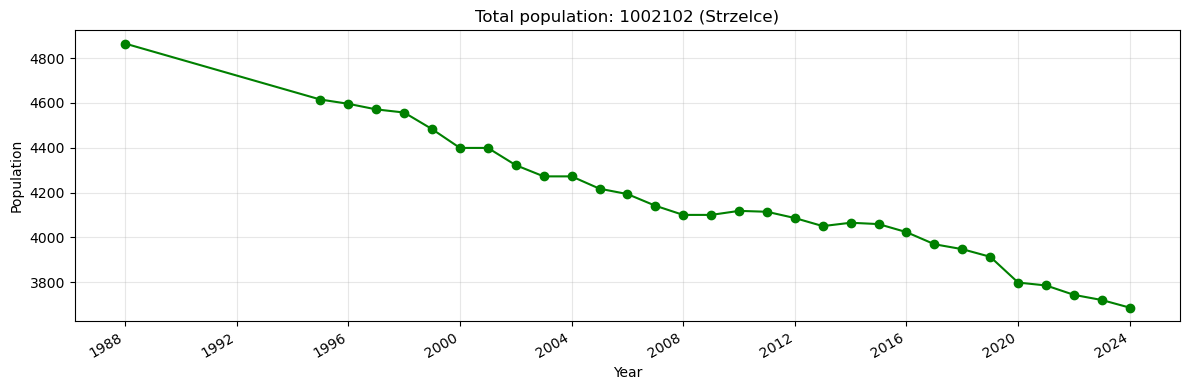

In [5]:
# =============================================================================
# STEP 5: Population Data (TERYTRecord.pop)
# =============================================================================

print(f"=== Population for {rec.teryt_id} ({rec.name}) ===\n")
print(f"Type: {type(rec.pop)}")
print(f"Index type: {type(rec.pop.index)}")
print(f"Years with data: {[ts.year for ts in rec.pop.dropna().index]}")
print(f"\n--- Population time series ---")
display(rec.pop)

# Plot population
fig, ax = plt.subplots(figsize=(12, 4))
rec.pop.dropna().plot(ax=ax, marker='o', linewidth=1.5, color='green')
ax.set_title(f"Total population: {rec.teryt_id} ({rec.name})")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# =============================================================================
# STEP 6: Urban/Rural Classification (TERYTRecord.pop_class)
# =============================================================================

print(f"=== Pop Classification for {rec.teryt_id} ({rec.name}) ===\n")
print(f"Rodz: {rec.rodz}")
print(f"pop_class type: {type(rec.pop_class)}")
print(f"pop_class shape: {rec.pop_class.shape}")
print(f"\n--- Classification table ---")
display(rec.pop_class)

=== Pop Classification for 1002102 (Strzelce) ===

Rodz: 2
pop_class type: <class 'pandas.core.frame.DataFrame'>
pop_class shape: (38, 2)

--- Classification table ---


,pop_class_code,pop_class_label
date,,
1988-01-01,1,wieś
1989-01-01,1,wieś
1990-01-01,1,wieś
1991-01-01,1,wieś
1992-01-01,1,wieś
1993-01-01,1,wieś
1994-01-01,1,wieś
1995-01-01,1,wieś
1996-01-01,1,wieś


In [7]:
# =============================================================================
# STEP 7: Dimension Label Coding (DataSeries.cat_code, cat_bounds)
# =============================================================================

print(f"=== Dimension Coding for {rec.teryt_id} ({rec.name}) ===\n")

# Show a few DataSeries with their cat_codes and cat_bounds
coded_series = [(k, s) for k, s in rec.data.items() if s.cat_code]
print(f"DataSeries with cat_code: {len(coded_series)} / {len(rec.data)}\n")

for key, series in coded_series[:8]:
    print(f"  {series}")
    print(f"    Categories: {series.categories}")
    print(f"    cat_code: {series.cat_code}")
    if series.cat_bounds:
        print(f"    cat_bounds: {series.cat_bounds}")
    print()

# Summary: show unique dimension codings for one subject
if coded_series:
    sample_sid = coded_series[0][1].subject_id
    subj_data = rec.get_data_by_subject(sample_sid)
    print(f"\n=== All coded categories for subject {sample_sid} ===")
    all_codes = {}
    for k, s in subj_data.items():
        for dim, cat in s.categories.items():
            code = s.cat_code.get(dim, '?')
            if dim not in all_codes:
                all_codes[dim] = []
            all_codes[dim].append((cat, code))
    
    for dim, pairs in all_codes.items():
        unique = sorted(set(pairs), key=lambda x: x[1] if isinstance(x[1], (int, float)) else 999)
        print(f"\n  Dimension {dim}:")
        for label, code in unique:
            print(f"    {code}: '{label}'")

=== Dimension Coding for 1002102 (Strzelce) ===

DataSeries with cat_code: 434 / 434

  DataSeries(BDL/P2137/47693, cats=[n1=60-64, n2=kobiety], 30 years [1995-2024])
    Categories: {'n1': '60-64', 'n2': 'kobiety'}
    cat_code: {'n1': 14, 'n2': 2}
    cat_bounds: {'n1': {'lower_bound': 60, 'upper_bound': 64}}

  DataSeries(BDL/P2137/47694, cats=[n1=25-29, n2=ogółem], 30 years [1995-2024])
    Categories: {'n1': '25-29', 'n2': 'ogółem'}
    cat_code: {'n1': 7, 'n2': 0}
    cat_bounds: {'n1': {'lower_bound': 25, 'upper_bound': 29}}

  DataSeries(BDL/P2137/47695, cats=[n1=30-34, n2=kobiety], 30 years [1995-2024])
    Categories: {'n1': '30-34', 'n2': 'kobiety'}
    cat_code: {'n1': 8, 'n2': 2}
    cat_bounds: {'n1': {'lower_bound': 30, 'upper_bound': 34}}

  DataSeries(BDL/P2137/47696, cats=[n1=25-29, n2=kobiety], 30 years [1995-2024])
    Categories: {'n1': '25-29', 'n2': 'kobiety'}
    cat_code: {'n1': 7, 'n2': 2}
    cat_bounds: {'n1': {'lower_bound': 25, 'upper_bound': 29}}

  DataS

In [8]:
d = rec.cross_tables['M_pop__age_sex'].get_as_dataframe(1995)
display(d)
d = rec.cross_tables['M_pop__age_sex'].get_as_dataframe(2005)
display(d)
d = rec.cross_tables['M_pop__age_sex'].get_as_dataframe(2020)
display(d)

,kobiety,mężczyźni,ogółem
0-4,162.0,169.0,331.0
10-14,164.0,185.0,349.0
15-19,149.0,170.0,319.0
20-24,169.0,182.0,351.0
25-29,152.0,156.0,308.0
30-34,148.0,132.0,280.0
35-39,165.0,193.0,358.0
40-44,138.0,167.0,305.0
45-49,152.0,153.0,305.0
5-9,170.0,179.0,349.0


,kobiety,mężczyźni,ogółem
0-4,90.0,100.0,190.0
10-14,153.0,150.0,303.0
15-19,155.0,166.0,321.0
20-24,143.0,173.0,316.0
25-29,131.0,161.0,292.0
30-34,145.0,146.0,291.0
35-39,130.0,140.0,270.0
40-44,134.0,120.0,254.0
45-49,145.0,177.0,322.0
5-9,111.0,137.0,248.0


,kobiety,mężczyźni,ogółem
0-4,76.0,102.0,178.0
10-14,93.0,101.0,194.0
15-19,94.0,101.0,195.0
20-24,98.0,108.0,206.0
25-29,124.0,132.0,256.0
30-34,125.0,148.0,273.0
35-39,117.0,147.0,264.0
40-44,131.0,134.0,265.0
45-49,145.0,146.0,291.0
5-9,94.0,88.0,182.0
